# Tuning weight of adversarial training and cycle consistency for ProtInt
Setting the dropout weight to be 0.1, we tested the model on several weights of adversarial training and cycle consistency, both in fixed and trainable dropout mode. We run the model in 5 random seeds to ensure statistical robustness and evaluate the weights by graph iLISI and cLISI scores from the scib package.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import scanpy as sc
import matplotlib.pyplot as plt
from protint.projection import decode_matrix, load_model
from protint.model_cvae import BatchCVAEFeatureWiseDropout

In [ ]:
import yaml
with open("../../config/config.local.yaml", "r") as f:
    config = yaml.safe_load(f)
basedir = config['code_dir']

anndata_input_dir = os.path.join(config['output_data_dir'], 
                         "processed_proteomics_data", 
                         "1_1_9_ProCan_FDL_PanCancer_merged_tissue20.h5ad"
)  # where the tumor and cell line data, in anndata format, are stored

scratch_run_dir = os.path.join(config['output_data_dir'], "protint_tune_adv_cyc_weight")  # where the output of the protint model will be stored
if not os.path.exists(scratch_run_dir):
    os.makedirs(scratch_run_dir)

In [3]:
from Utils.helper_functions import reconstruct_with_original_batch, run_lisi_at_k
from Utils.plot_functions import joint_umap_original_reconstructed, plot_detected_reconstructed_imputed_histogram
from Utils.color_palette import tissue_palette, integration_mode_colors

In [4]:

def load_loss_file(path, label):
    if not os.path.exists(path):
        print(f"⚠️ Warning: {label} file not found: {path}")
        return None
    df = pd.read_csv(path, sep="\t")
    if "epoch" not in df or "value" not in df:
        raise ValueError(f"File {path} requires 'epoch' & 'value' columns.")
    return df

## Plotting initial data

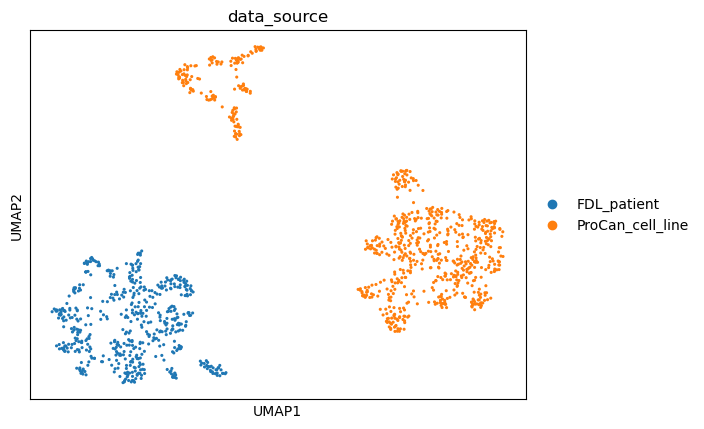

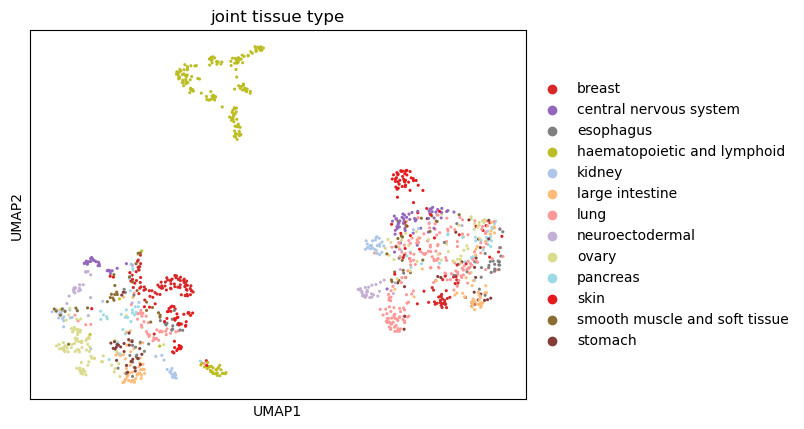

In [5]:
adata = sc.read_h5ad(anndata_input_dir)
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata, color="data_source", size=20)
sc.pl.umap(adata, color="joint tissue type", size=20, palette=tissue_palette)

## Tuning the weight for adversarial training
Here the src_adv_weight is varied and the cyc_weight was kept at 0

In [6]:
src_adv_weights = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4]
seeds = [11,12,13,14,15]
result_src_adv = []

loss_file = os.path.join(scratch_run_dir, "metrics", "train_loss_rec")

for src_adv_weight in src_adv_weights:
    for seed in seeds:
        print(f"Running with src_adv_weight={src_adv_weight}, seed={seed}")
        # Training
        cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "3000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", "0.1",
            "--src_adv_weight", str(src_adv_weight),
            "--cyc_weight", "0",
            "--output_dir", scratch_run_dir,
            "--random_seed", str(seed)
        ]
        result = subprocess.run(cmd, check=False)
        print("Return code:", result.returncode)

        # projection
        cmd = [
            "protint", "projection",
            "--projection_file", anndata_input_dir,
            "--model_dir", os.path.join(scratch_run_dir, "models"),
            "--onto", "FDL_patient",
            "--output_file", os.path.join(scratch_run_dir, "projection.h5ad"),
        ]

        result = subprocess.run(cmd, check=False)

        projected_adata = sc.read_h5ad(os.path.join(scratch_run_dir, "projection.h5ad"))

        # record training loss
        df_loss = load_loss_file(loss_file, "train_loss_rec")
        rec_loss = df_loss["value"].iloc[-1]   # endpoint only

        # compute iLISI and cLISI scores
        metrics = run_lisi_at_k(
            projected_adata,
            ks=[15],
            batch_key="data_source",
            prefix="ProtInt",
            n_pcs=50,
        )

        result_src_adv.append({
                "seed": seed,
                "src_adv_weight": src_adv_weight,
                "reconstruction_loss": rec_loss,
                "iLISI": metrics[f"ProtInt_k15_iLISI"],
                "cLISI": metrics[f"ProtInt_k15_cLISI_tissue"]
            })
result_src_adv_df = pd.DataFrame(result_src_adv)

Running with src_adv_weight=0, seed=11
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2383.971612414837
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with src_adv_weight=0, seed=12
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2370.70117335352
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with src_adv_weight=0, seed=13
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2400.875141937926
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with src_adv_weight=0, seed=14
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2435.372113928842
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with 

## Tuning the dropout parameters on trainable dropout parameters
Here the src_adv_weight is set to 0 and the cyc_weight varied. The rho and zeta parameters were set to be trainable by setting train_dropout. 

In [7]:
cyc_weights = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4]
seeds = [11,12,13,14,15]
result_cyc = []

loss_file = os.path.join(scratch_run_dir, "metrics", "train_loss_rec")

for cyc_weight in cyc_weights:
    for seed in seeds:
        print(f"Running with cyc_weight={cyc_weight}, seed={seed}")
        # Training
        cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "3000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", "0.1",
            "--src_adv_weight", "0",
            "--cyc_weight", str(cyc_weight),
            "--output_dir", scratch_run_dir,
            "--random_seed", str(seed)
        ]
        result = subprocess.run(cmd, check=False)
        print("Return code:", result.returncode)

        # projection
        cmd = [
            "protint", "projection",
            "--projection_file", anndata_input_dir,
            "--model_dir", os.path.join(scratch_run_dir, "models"),
            "--onto", "FDL_patient",
            "--output_file", os.path.join(scratch_run_dir, "projection.h5ad"),
        ]

        result = subprocess.run(cmd, check=False)

        projected_adata = sc.read_h5ad(os.path.join(scratch_run_dir, "projection.h5ad"))

        # record training loss
        df_loss = load_loss_file(loss_file, "train_loss_rec")
        rec_loss = df_loss["value"].iloc[-1]   # endpoint only

        # compute iLISI and cLISI scores
        metrics = run_lisi_at_k(
            projected_adata,
            ks=[15],
            batch_key="data_source",
            prefix="ProtInt",
            n_pcs=50,
        )

        result_cyc.append({
                "seed": seed,
                "cyc_weight": cyc_weight,
                "reconstruction_loss": rec_loss,
                "iLISI": metrics[f"ProtInt_k15_iLISI"],
                "cLISI": metrics[f"ProtInt_k15_cLISI_tissue"]
            })
result_cyc_df = pd.DataFrame(result_cyc)

Running with cyc_weight=0, seed=11
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2383.971612414837
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, seed=12
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2370.70117335352
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, seed=13
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2400.875141937926
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, seed=14
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2435.372113928842
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, se

## Run an example of cycle consistency

In [8]:
# run an example with the selected dropout weight to compare UMAP with the option when trainable dropout is on vs off
cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "3000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", "0.1",
            "--src_adv_weight", "0",
            "--cyc_weight", "0.1",
            "--output_dir", scratch_run_dir,
            "--train_dropout"
        ]
result = subprocess.run(cmd, check=False)
print("Return code:", result.returncode)

Using device: cuda
Return code: 0


In [9]:
cmd = [
    "protint", "projection",
    "--projection_file", anndata_input_dir,
    "--model_dir", os.path.join(scratch_run_dir, "models"),
    "--onto", "FDL_patient",
    "--output_file", os.path.join(scratch_run_dir, "projection.h5ad"),
]

result = subprocess.run(cmd, check=False)

print("Return code:", result.returncode)

Loaded model epoch: 2999, loss 2315.8678084784256
Return code: 0


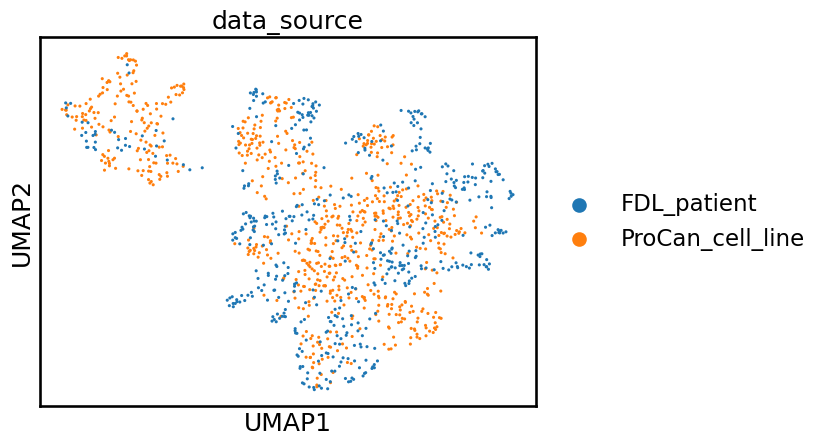

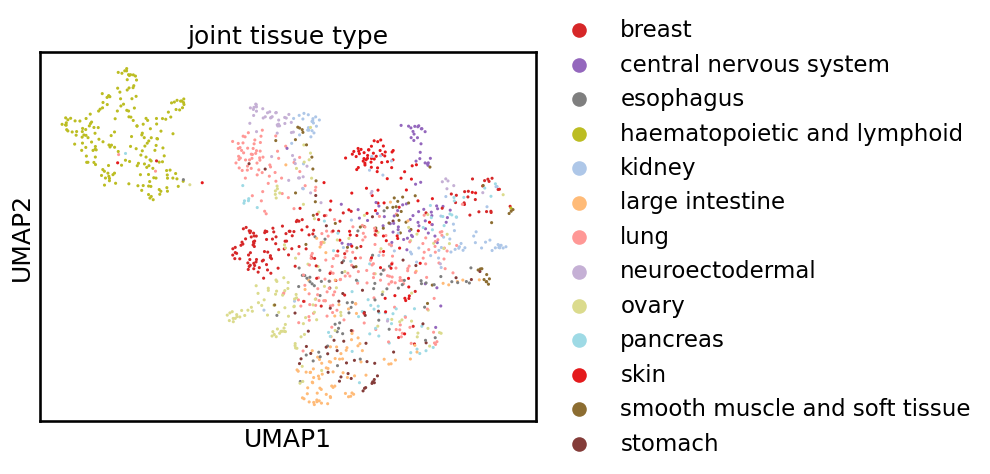

In [10]:
# import the projected data and visualize
adata_projected = sc.read_h5ad(os.path.join(scratch_run_dir, "projection.h5ad"))

# Copy harmonized color palette
adata_projected.uns["joint tissue type_colors"] = adata.uns["joint tissue type_colors"].copy()
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata_projected, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata_projected, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata_projected, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata_projected, color="data_source", size=20)
sc.pl.umap(adata_projected, color="joint tissue type", size=20, palette=tissue_palette)

In [11]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, features, label_encode = load_model(
    os.path.join(scratch_run_dir, "models"),
    device,
    model_cls=BatchCVAEFeatureWiseDropout,
)
# Important: same feature order as training/model
adata = adata[:, features].copy()

recon_adata, z_adata = reconstruct_with_original_batch(
    model=model,
    adata=adata,
    label_encode=label_encode,
    decode_matrix=decode_matrix,
    batch_key="data_source",   # replace with your adata.obs column
    device=device,
    decimals=4,
    batch_size=1600,
)

Loaded model epoch: 2999, loss 2315.8678084784256


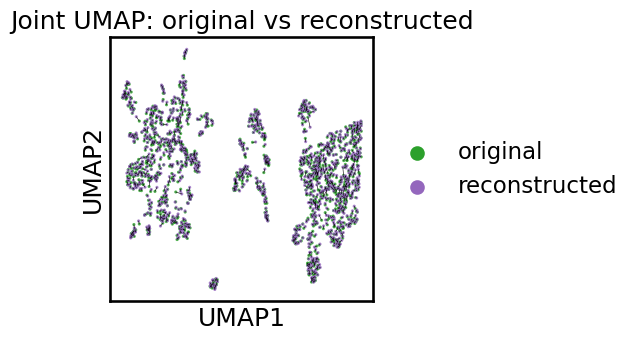

In [12]:
joint, fig, ax = joint_umap_original_reconstructed(
    adata,
    recon_adata,
    detected_layer="detected"
)

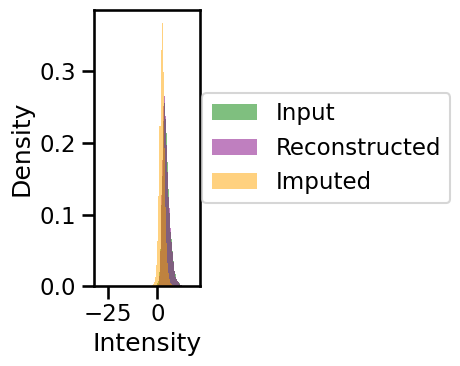

In [13]:
plot_detected_reconstructed_imputed_histogram(
    adata,
    recon_adata)

## Compare the reconstruction loss 

In [14]:


# -----------------------------
# 1) Prepare combined dataframe
# -----------------------------
src_adv_df = result_src_adv_df.copy()
src_adv_df["mode"] = "adversarial training"
src_adv_df["weight"] = src_adv_df["src_adv_weight"]

cyc_df = result_cyc_df.copy()
cyc_df["mode"] = "cycle consistency"
cyc_df["weight"] = cyc_df["cyc_weight"]

plot_df = pd.concat(
    [
        src_adv_df[["seed", "mode", "weight", "reconstruction_loss", "iLISI", "cLISI"]],
        cyc_df[["seed", "mode", "weight", "reconstruction_loss", "iLISI", "cLISI"]],
    ],
    ignore_index=True,
)

In [15]:
def plot_metric(
    plot_df,
    metric,
    ylabel,
    yscale=None,
    yrange: list[float, float] = None,
):
    plt.figure(figsize=(12, 5))

    for mode, df_mode in plot_df.groupby("mode"):
        color = integration_mode_colors[mode]

        # Individual observations
        plt.scatter(
            df_mode["weight"],
            df_mode[metric],
            alpha=0.55,
            color=color,
            label=f"{mode}",
        )

        # Mean at each weight
        df_mean = (
            df_mode.groupby("weight", as_index=False)[metric]
            .mean()
            .sort_values("weight")
        )

        # Line through the means
        plt.plot(
            df_mean["weight"],
            df_mean[metric],
            color=color,
            linewidth=2,
        )

    plt.xscale("symlog", linthresh=1e-5)

    if yscale is not None:
        plt.yscale(yscale)

    if yrange is not None:
        plt.ylim(yrange[0], yrange[1])

    plt.xlabel("Weight")
    plt.ylabel(ylabel)
    plt.grid(True, which="both", alpha=0.3)

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0,
    )

    plt.tight_layout()
    plt.show()

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").le

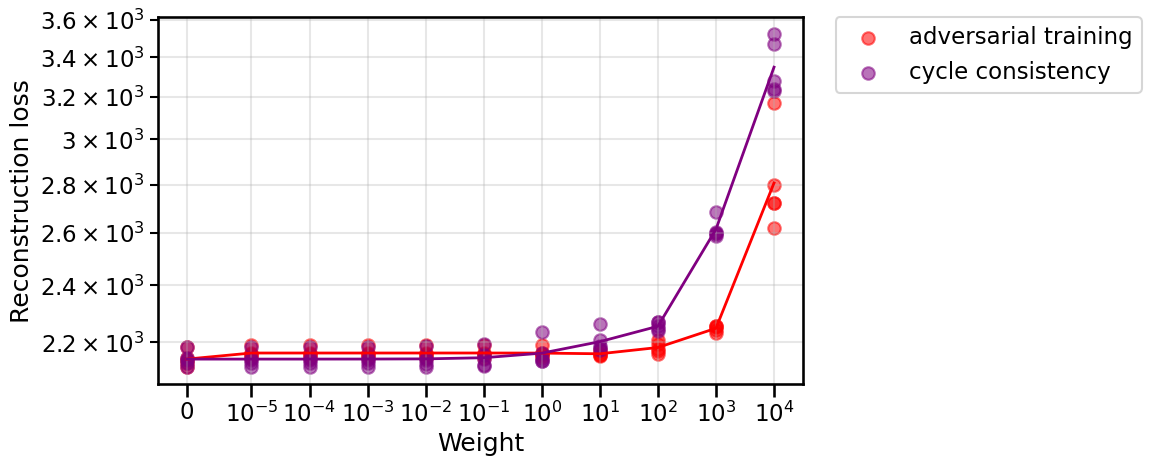

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


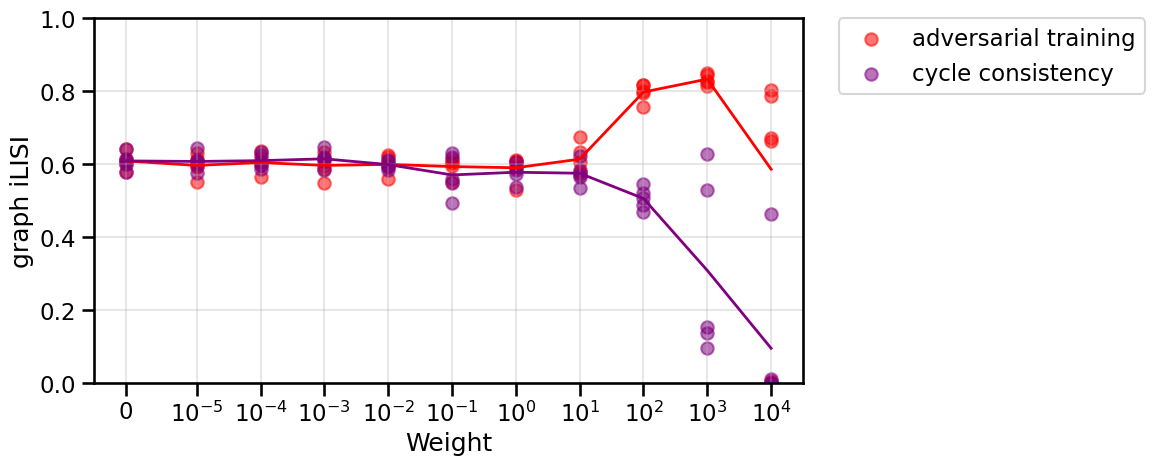

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


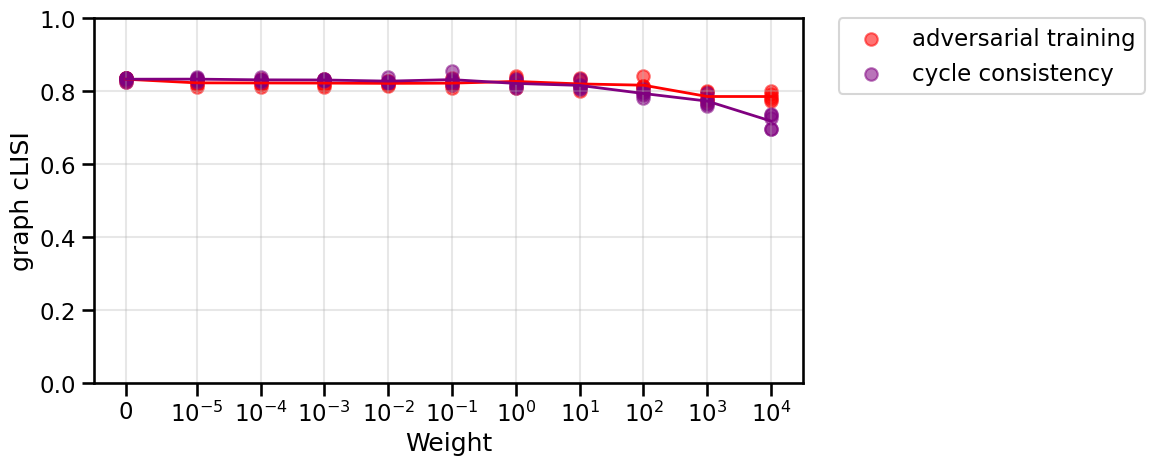

In [16]:
plot_metric(
    plot_df=plot_df,
    metric="reconstruction_loss",
    ylabel="Reconstruction loss",
    yscale="log",
)

plot_metric(
    plot_df=plot_df,
    metric="iLISI",
    ylabel="graph iLISI",
    yrange=[0, 1]
)

plot_metric(
    plot_df=plot_df,
    metric="cLISI",
    ylabel="graph cLISI",
    yrange=[0, 1]
)

In [17]:
plot_df.to_csv(os.path.join(scratch_run_dir, "tune_adv_cyc_weight_results_fixed_dropout.csv"), index=False)

## Tuning weight with trainable dropout parameters

In [18]:
src_adv_weights = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4]
seeds = [11,12,13,14,15]
result_src_adv = []

loss_file = os.path.join(scratch_run_dir, "metrics", "train_loss_rec")

for src_adv_weight in src_adv_weights:
    for seed in seeds:
        print(f"Running with src_adv_weight={src_adv_weight}, seed={seed}")
        # Training
        cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "3000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", "0.1",
            "--src_adv_weight", str(src_adv_weight),
            "--cyc_weight", "0",
            "--output_dir", scratch_run_dir,
            "--random_seed", str(seed),
            "--train_dropout"
        ]
        result = subprocess.run(cmd, check=False)
        print("Return code:", result.returncode)

        # projection
        cmd = [
            "protint", "projection",
            "--projection_file", anndata_input_dir,
            "--model_dir", os.path.join(scratch_run_dir, "models"),
            "--onto", "FDL_patient",
            "--output_file", os.path.join(scratch_run_dir, "projection.h5ad"),
        ]

        result = subprocess.run(cmd, check=False)

        projected_adata = sc.read_h5ad(os.path.join(scratch_run_dir, "projection.h5ad"))

        # record training loss
        df_loss = load_loss_file(loss_file, "train_loss_rec")
        rec_loss = df_loss["value"].iloc[-1]   # endpoint only

        # compute iLISI and cLISI scores
        metrics = run_lisi_at_k(
            projected_adata,
            ks=[15],
            batch_key="data_source",
            prefix="ProtInt",
            n_pcs=50,
        )

        result_src_adv.append({
                "seed": seed,
                "src_adv_weight": src_adv_weight,
                "reconstruction_loss": rec_loss,
                "iLISI": metrics[f"ProtInt_k15_iLISI"],
                "cLISI": metrics[f"ProtInt_k15_cLISI_tissue"]
            })
result_src_adv_df = pd.DataFrame(result_src_adv)

Running with src_adv_weight=0, seed=11
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2300.875189250568
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with src_adv_weight=0, seed=12
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2286.8793054504163
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with src_adv_weight=0, seed=13
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2312.6666351249055
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with src_adv_weight=0, seed=14
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2350.320827024981
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running wi

In [19]:
cyc_weights = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4]
seeds = [11,12,13,14,15]
result_cyc = []

loss_file = os.path.join(scratch_run_dir, "metrics", "train_loss_rec")

for cyc_weight in cyc_weights:
    for seed in seeds:
        print(f"Running with cyc_weight={cyc_weight}, seed={seed}")
        # Training
        cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "3000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", "0.1",
            "--src_adv_weight", "0",
            "--cyc_weight", str(cyc_weight),
            "--output_dir", scratch_run_dir,
            "--random_seed", str(seed)
        ]
        result = subprocess.run(cmd, check=False)
        print("Return code:", result.returncode)

        # projection
        cmd = [
            "protint", "projection",
            "--projection_file", anndata_input_dir,
            "--model_dir", os.path.join(scratch_run_dir, "models"),
            "--onto", "FDL_patient",
            "--output_file", os.path.join(scratch_run_dir, "projection.h5ad"),
        ]

        result = subprocess.run(cmd, check=False)

        projected_adata = sc.read_h5ad(os.path.join(scratch_run_dir, "projection.h5ad"))

        # record training loss
        df_loss = load_loss_file(loss_file, "train_loss_rec")
        rec_loss = df_loss["value"].iloc[-1]   # endpoint only

        # compute iLISI and cLISI scores
        metrics = run_lisi_at_k(
            projected_adata,
            ks=[15],
            batch_key="data_source",
            prefix="ProtInt",
            n_pcs=50,
        )

        result_cyc.append({
                "seed": seed,
                "cyc_weight": cyc_weight,
                "reconstruction_loss": rec_loss,
                "iLISI": metrics[f"ProtInt_k15_iLISI"],
                "cLISI": metrics[f"ProtInt_k15_cLISI_tissue"]
            })
result_cyc_df = pd.DataFrame(result_cyc)

Running with cyc_weight=0, seed=11
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2383.971612414837
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, seed=12
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2370.70117335352
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, seed=13
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2400.875141937926
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, seed=14
Using device: cuda
Return code: 0
Loaded model epoch: 2999, loss 2435.372113928842
[LISI:ProtInt] use_rep=None, computing PCA with n_pcs=50
[LISI:ProtInt] Running neighbors with k=15, use_rep=X_pca, n_pcs=50
Running with cyc_weight=0, se

In [20]:


# -----------------------------
# 1) Prepare combined dataframe
# -----------------------------
src_adv_df = result_src_adv_df.copy()
src_adv_df["mode"] = "adversarial training"
src_adv_df["weight"] = src_adv_df["src_adv_weight"]

cyc_df = result_cyc_df.copy()
cyc_df["mode"] = "cycle consistency"
cyc_df["weight"] = cyc_df["cyc_weight"]

plot_df = pd.concat(
    [
        src_adv_df[["seed", "mode", "weight", "reconstruction_loss", "iLISI", "cLISI"]],
        cyc_df[["seed", "mode", "weight", "reconstruction_loss", "iLISI", "cLISI"]],
    ],
    ignore_index=True,
)

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


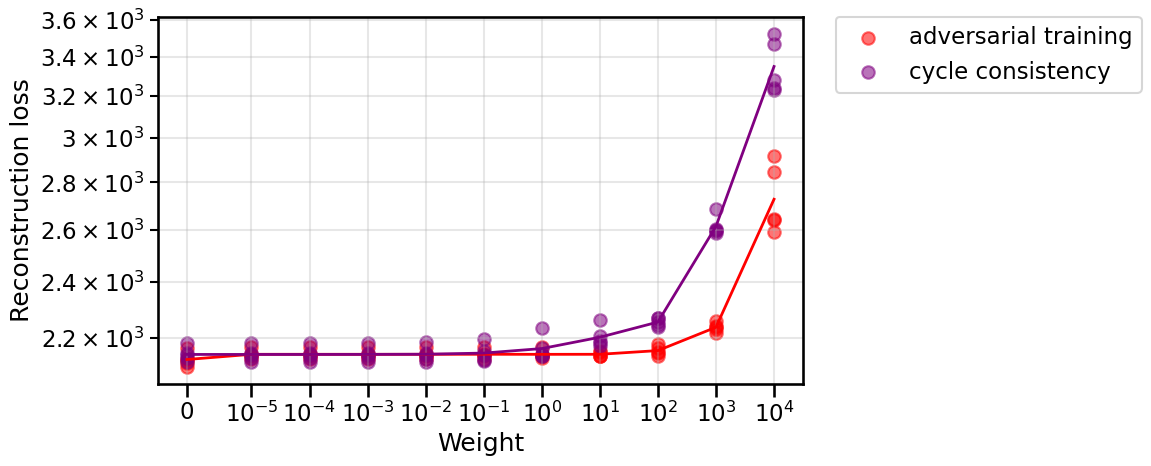

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


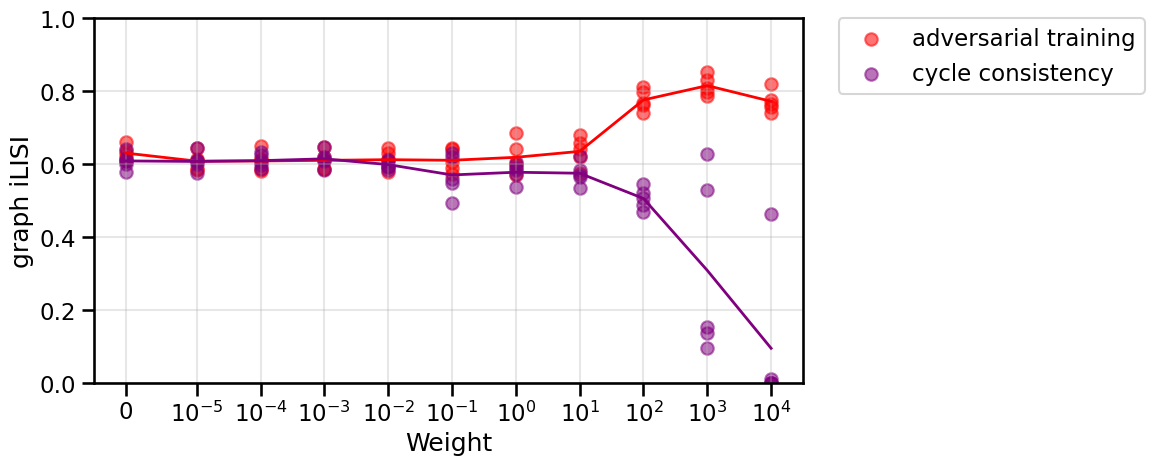

/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/local-conda-envs/tacongqu/protint/lib/python3.11/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


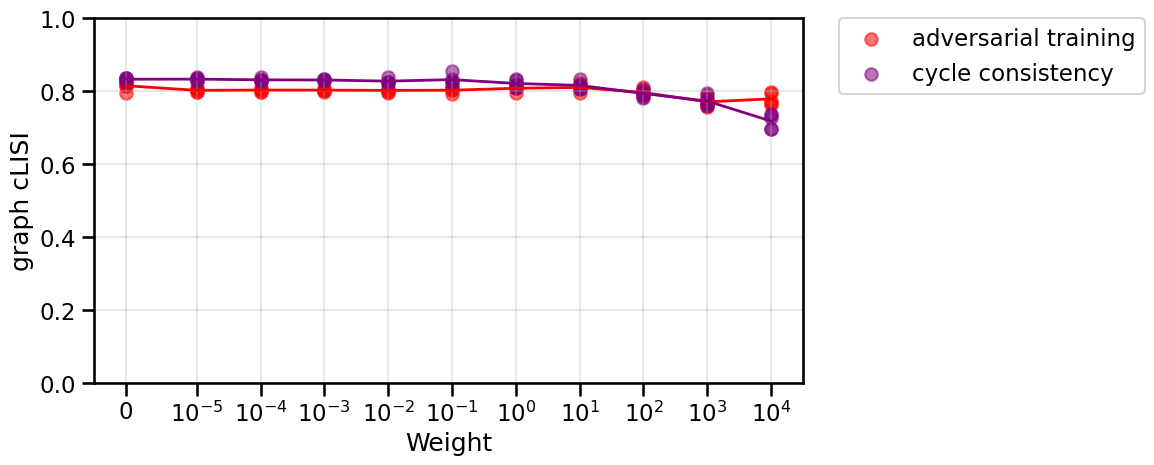

In [21]:
plot_metric(
    plot_df=plot_df,
    metric="reconstruction_loss",
    ylabel="Reconstruction loss",
    yscale="log",
)

plot_metric(
    plot_df=plot_df,
    metric="iLISI",
    ylabel="graph iLISI",
    yrange=[0, 1]
)

plot_metric(
    plot_df=plot_df,
    metric="cLISI",
    ylabel="graph cLISI",
    yrange=[0, 1]
)

In [22]:
plot_df.to_csv(os.path.join(scratch_run_dir, "tune_adv_cyc_weight_results_trainable_dropout.csv"), index=False)